# **Facial Emotion Detection**

## **Problem Definition**

**The context:** Why is this problem important to solve?<br>
  * Today's software can read what you type and click, but it has no idea how you feel. Facial emotion recognition changes that — it lets a system look at a person's face and identify their emotional state, then act on it.
  * The applications span multiple sectors. In human-machine interaction, systems can adapt dynamically — detecting frustration and surfacing help, or recognizing confusion and adjusting the flow.
  * In mental health, automated emotion detection can support early screening and continuous monitoring at a scale clinical staff cannot cover manually.
  * In customer service and marketing, businesses gain real-time insight into customer reactions, enabling faster response and better-targeted engagement.
  * In security and surveillance, emotion signals can flag anomalous behavior for review before incidents escalate.
  * In gaming and education, adaptive systems can respond to user engagement levels, improving retention and outcomes.
  * Solving this problem is a core building block for emotionally intelligent systems — technology that responds not only to user input, but to user state. The result is measurable improvement in engagement, efficiency, and decision-making across industries.

**The objectives:** What is the intended goal?<br>
  * The goal is to build a deep learning model that classifies facial images into four emotion categories — happy, sad, surprise, and neutral — with high accuracy on unseen data. Specifically, the project aims to:

    * Train and compare multiple model architectures, including custom CNNs built from scratch and pre-trained transfer learning models (VGG16, ResNet, EfficientNet).
    * Determine which approach performs best on 48x48 grayscale facial images, and understand why.
    * Tune the strongest model to maximize accuracy and generalization on unseen test data.
    * Evaluate performance across all four emotion classes to identify where the model succeeds and where it fails.
    * Deliver a final model recommendation suitable for real-world deployment.

**The key questions:** What are the key questions that need to be answered?<br>
  * Can a deep learning model accurately classify facial expressions into the four emotion categories, and what accuracy is achievable on unseen data?
  * Which architecture performs best for this problem — a CNN built from scratch, or a pre-trained transfer learning model?
  * Does color mode matter? Since the source images are grayscale, does converting them to RGB improve performance or add unnecessary cost?
  * Which emotions are hardest to classify, and why? Where does the model make the most mistakes?
  * What factors limit performance — the model architecture, the image resolution, or the quality of the labels themselves?
  * Can tuning meaningfully improve the best model, and which changes deliver the largest gain?
  * Is the final model reliable enough for real-world deployment, and what would need to change before it is?

**The problem formulation:** What are we trying to solve using data science?
  * We are using data science to turn raw facial images into an automated emotion prediction system. Rather than requiring a human to interpret expressions manually, we train a model to recognize emotional states directly from image data — at scale, in real time, and consistently. More detailed:
      * Converting an unstructured input (a face image) into a structured, actionable output (a predicted emotion with a confidence level).
      * Enabling systems to respond automatically to a user's emotional state, rather than waiting for explicit input.
  * The end result is a model that lets businesses detect and act on human emotion without human involvement in the loop.


## **About the dataset**

The data set consists of 3 folders, i.e., 'test', 'train', and 'validation'.
Each of these folders has four subfolders:

**‘happy’**: Images of people who have happy facial expressions.<br>
**‘sad’**: Images of people with sad or upset facial expressions.<br>
**‘surprise’**: Images of people who have shocked or surprised facial expressions.<br>
**‘neutral’**: Images of people showing no prominent emotion in their facial expression at all.<br>


## **Mounting the Drive**

**NOTE:**  Please use Google Colab from your browser for this notebook. **Google.colab is NOT a library that can be downloaded locally on your device.**

In [ ]:
# Mountding the drive
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## **Importing the Libraries**

In [ ]:
# Import necessary libraries
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
import random
import tensorflow as tf
import tensorflow.keras.applications as ap
from pathlib import Path
from collections import Counter
from PIL import Image

# Deep learning libraries
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import (Dense, Input, Dropout, GlobalAveragePooling2D,
                                     Flatten, Conv2D, BatchNormalization,
                                     Activation, MaxPooling2D, LeakyReLU)
from tensorflow.keras import backend
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input as vgg_pre
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_pre
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre
from tensorflow.keras.losses import CategoricalCrossentropy
from sklearn.metrics import classification_report, confusion_matrix

# Default plot style
plt.style.use('seaborn-v0_8-pastel')

In [ ]:
# Using random seed value to get static results. Otherwise, models generating slighlty different result on each run

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

### **Let us load and unzip the data**

**Note:**
- You must download the dataset from the link provided on Olympus and upload the same on your Google drive before executing the code in the next cell.
- In case of any error, please make sure that the path of the file is correct as the path may be different for you.

In [ ]:
#Provide input file path and extract data from Zip file
path = '/content/Facial_emotion_images.zip'

with zipfile.ZipFile(path, 'r') as zip_ref:
    zip_ref.extractall()

## **Visualizing our Classes**

Let's look at our classes.

**Write down your observation for each class. What do you think can be a unique feature of each emotion, that separates it from the remaining classes?**

### **Happy**

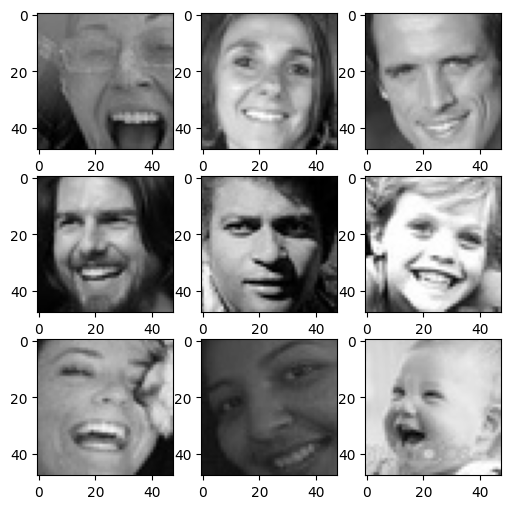

In [ ]:
# provide path for happy images and plot images
emotion = 'happy'
path = '/content/Facial_emotion_images/'
pict_size = 48

plt.figure(figsize= (6,6))
for i in range(1, 10, 1):
    plt.subplot(3, 3, i)

    img = load_img(path + 'train/' + emotion + '/' +
                  os.listdir(path + 'train/' + emotion)[i], target_size = (pict_size, pict_size))
    plt.imshow(img)

plt.show()

**Observations and Insights:**

*   Happy faces are marked by a smile (upturned mouth, often showing teeth) and raised cheeks, sometimes with crinkled eyes.
*   The mouth is a strong, consistent feature that separates happy from the other classes, making it relatively distinct.
*   Images are low-res 48×48 grayscale with varied pose and lighting.

### **Sad**

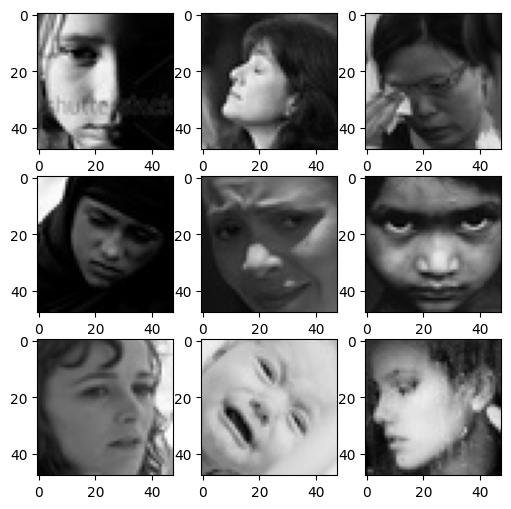

In [ ]:
# provide path for sad images and plot images
emotion = 'sad'
path = '/content/Facial_emotion_images/'
pict_size = 48

plt.figure(figsize= (6,6))
for i in range(1, 10, 1):
    plt.subplot(3, 3, i)

    img = load_img(path + 'train/' + emotion + '/' +
                  os.listdir(path + 'train/' + emotion)[i], target_size = (pict_size, pict_size))
    plt.imshow(img)

plt.show()

**Observations and Insights:**

*   Sad faces show downturned mouth corners and drooping/angled eyebrows, with an overall low-energy expression.


### **Neutral**

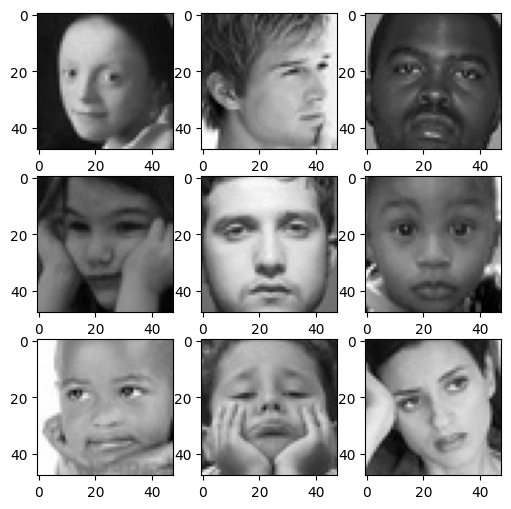

In [ ]:
# provide path for neutral images and plot images
emotion = 'neutral'
path = '/content/Facial_emotion_images/'
pict_size = 48

plt.figure(figsize= (6,6))
for i in range(1, 10, 1):
    plt.subplot(3, 3, i)

    img = load_img(path + 'train/' + emotion + '/' +
                  os.listdir(path + 'train/' + emotion)[i], target_size = (pict_size, pict_size))
    plt.imshow(img)

plt.show()

**Observations and Insights:**

*   Neutral faces show a relaxed, expressionless look — mouth roughly flat (no smile or frown), level eyebrows, and eyes open normally. With no strong defining feature.

### **Surprised**

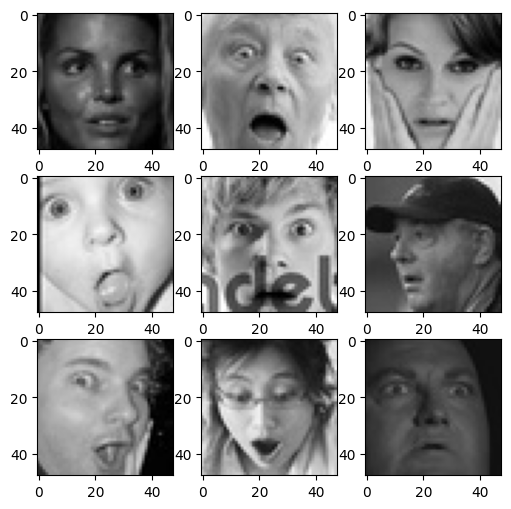

In [ ]:
# provide path for surprise images and plot images
emotion = 'surprise'
path = '/content/Facial_emotion_images/'
pict_size = 48

plt.figure(figsize= (6,6))
for i in range(1, 10, 1):
    plt.subplot(3, 3, i)

    img = load_img(path + 'train/' + emotion + '/' +
                  os.listdir(path + 'train/' + emotion)[i], target_size = (pict_size, pict_size))
    plt.imshow(img)

plt.show()

**Observations and Insights:**

*   Surprised faces show wide-open eyes, raised eyebrows, and an open mouth (often a dropped jaw or "O" shape).
*   These are strong, distinct cues, making surprise one of the easiest classes to separate from the others.

## **Checking Distribution of Classes**

In [ ]:
# count items in the happy folder and printing count
dist_happy = len(os.listdir(path + 'train/happy'))
print('We have ', dist_happy, 'images in the "Happy" Class')

# count items in the sad folder and printing count
dist_sad = len(os.listdir(path + 'train/sad'))
print('We have ', dist_sad, 'images in the "Sad" Class')

# count items in the neutral folder and printing count
dist_neutral = len(os.listdir(path + 'train/neutral'))
print('We have ', dist_neutral, 'images in the "Neutral" Class')

# count items in the surprise folder and printing count
dist_surprise = len(os.listdir(path + 'train/surprise'))
print('We have ', dist_surprise, 'images in the "Surprise" Class')

We have  3976 images in the "Happy" Class
We have  3982 images in the "Sad" Class
We have  3978 images in the "Neutral" Class
We have  3173 images in the "Surprise" Class


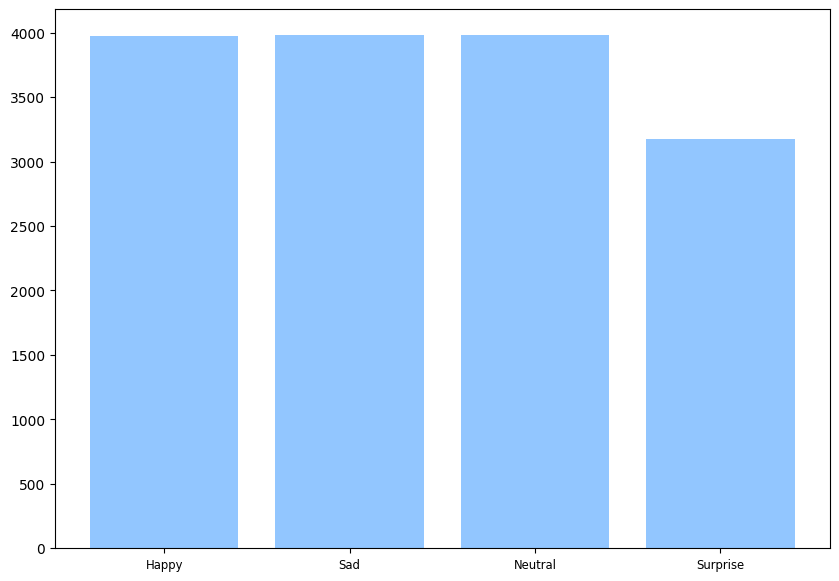

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [ ]:
# Plotting distribution for each class
plt.figure(figsize = (10, 7))

data = {'Happy': dist_happy, 'Sad': dist_sad, 'Neutral': dist_neutral, 'Surprise' : dist_surprise}

df = pd.Series(data)

plt.bar(range(len(df)), df.values, align = 'center')
plt.xticks(range(len(df)), df.index.values, size = 'small')

plt.show()
print(plt.style.available)

**Think About It:**
* Are the classes equally distributed? If not, do you think the imbalance is too high? Will it be a problem as we progress?
* Are there any Exploratory Data Analysis tasks that we can do here? Would they provide any meaningful insights?

**Observations and Insights:**


*   We are seeing total of 3976 images in the 'Happy' Class
*   We are seeing total of 3982 images in the 'Sad' Class
*   We are seeing total of 3978 images in the 'Neutral' Class
*   We are seeing total of 3173 images in the 'Surprise' Class
*   Classes are near-balanced: Happy, Sad, and Neutral each sit around ~3,980, while Surprise trails at ~3,170 — a mild imbalance.
*   Since the imbalance is slight, it shouldn't bias the model meaningfully; at most expect slightly weaker recall on Surprise.

In [ ]:
# Lets audit the training images: confirm all are the same size and color mode
# before building data loaders, so img_size and color_mode are set correctly.
root = Path('/content/Facial_emotion_images/train')
shapes, modes = Counter(), Counter()   # total unique dimensions and color modes

for img_path in root.rglob("*"):       # recurse through every class subfolder
    if img_path.is_file():
        try:
            with Image.open(img_path) as im:
                shapes[im.size] += 1   # (width, height)
                modes[im.mode] += 1    # 'L' = grayscale, 'RGB' = 3-channel
        except Exception:
            pass                       # ignore non-image files (e.g. hidden/system files)

print("Distinct sizes:", shapes)
print("Distinct modes:", modes)

Distinct sizes: Counter({(48, 48): 15109})
Distinct modes: Counter({'L': 15109})


**Are there any Exploratory Data Analysis tasks that we can do here? Would they provide any meaningful insights?**

**Observations:**


*  Every one of the 15,109 training images is 48×48 and mode 'L' (true single-channel grayscale).



## **Creating our Data Loaders**

In this section, we are creating data loaders that we will use as inputs to our Neural Network.

**You have two options for the color_mode. You can set it to color_mode = 'rgb' or color_mode = 'grayscale'. You will need to try out both and see for yourself which one gives better performance.**

In [ ]:
# Function that builds a fresh set of training callbacks for a given model.
# Passing model_name keeps each model's saved weights in its own file, so
# training one model never overwrites another's checkpoint.
# patience defaults to 3, but can be raised (e.g. 10 for tuning).

def make_callbacks(model_name, patience=3):

    # Save the best weights (highest val_accuracy) to disk during training
    checkpoint = ModelCheckpoint(
        f'./{model_name}.keras',
        monitor='val_accuracy',
        verbose=1,
        save_best_only=True,
        mode='max'
    )

    # Stop training once val_accuracy stops improving, and roll back to the best epoch
    early_stopping = EarlyStopping(
        monitor='val_accuracy',
        min_delta=0,
        patience=patience,
        verbose=1,
        restore_best_weights=True
    )

    # If accuracy stops improving, lower the learning rate so the model can fine-tune in smaller steps
    reduce_learningrate = ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.2,
        patience=3,
        verbose=1,
        min_delta=0.0001
    )

    return [early_stopping, reduce_learningrate, checkpoint]

epochs = 30

In [ ]:
# Builds the train, validation, and test data loaders for a model.
# color_mode picks 'grayscale' or 'rgb';
# preprocessing for transfer models (VGG/ResNet/EfficientNet)

def make_data_loaders(color_mode, rescale=None, preprocessing=None):
    batch_size = 32
    img_size = 48
    class_names = ['happy', 'sad', 'neutral', 'surprise']

# Training images: add random flips, brightness, and shear so the model sees more variety and overfits less
    datagen_train = ImageDataGenerator(horizontal_flip=True,
                                       brightness_range=(0.7, 1.3),
                                       shear_range=0.3,
                                       rescale=rescale,
                                       preprocessing_function=preprocessing)

# Create a generator for validation and test images that only rescales/preprocesses them, with no augmentation
    datagen_eval = ImageDataGenerator(rescale=rescale,
                                      preprocessing_function=preprocessing)

# Load training images from folders; shuffle for better learning
    train_set = datagen_train.flow_from_directory(path + "train",
                                                  target_size=(img_size, img_size),
                                                  color_mode=color_mode,
                                                  batch_size=batch_size,
                                                  class_mode='categorical',
                                                  classes=class_names,
                                                  shuffle=True,
                                                  seed=SEED)

# Load validation images, used to check the model during training
    validation_set = datagen_eval.flow_from_directory(path + "validation",
                                                      target_size=(img_size, img_size),
                                                      color_mode=color_mode,
                                                      batch_size=batch_size,
                                                      class_mode='categorical',
                                                      classes=class_names,
                                                      shuffle=True,
                                                      seed=SEED)

# Load test images; no shuffle so labels stay lined up for the confusion matrix
    test_set = datagen_eval.flow_from_directory(path + "test",
                                                target_size=(img_size, img_size),
                                                color_mode=color_mode,
                                                batch_size=batch_size,
                                                class_mode='categorical',
                                                classes=class_names,
                                                shuffle=False,
                                                seed=SEED)
    return train_set, validation_set, test_set

## **Model Building**

**Think About It:**
* Are Convolutional Neural Networks the right approach? Should we have gone with Artificial Neural Networks instead?
* What are the advantages of CNNs over ANNs and are they applicable here?

*   CNNs make more sense for face image data. CNN looks at the picture in small patches and reuse the same filters across the whole image, so they pick up on local patterns like edges and curves without needing a separate weight for every pixel.
*   That keeps the parameter count way down and means the model recognizes a feature whether it's centered or off to the side. They also build features up in layers — edges first, then parts like eyes and mouths, then full expressions — which is basically how human read a face anyway.

*   A plain ANN can't do any of that. We will need to flatten the image first, which throws away all the spatial info (like where was the eye in relation to the nose), and we'd end up with a massive number of weights that overfit fast and still don't perform as well. So for 48x48 face images, a CNN is the clear choice.

### **Creating the Base Neural Network**

In [ ]:
model1 = Sequential()

# First Convolutional Block
model1.add(Conv2D(64, (2, 2), input_shape = (48, 48, 1), padding = 'same'))
model1.add(LeakyReLU(0.1))
model1.add(MaxPooling2D(2, 2))
model1.add(Dropout(0.2))

# Second Convolutional Block
model1.add(Conv2D(32, (2, 2), padding = 'same'))
model1.add(LeakyReLU(0.1))
model1.add(MaxPooling2D(2, 2))
model1.add(Dropout(0.2))

# Third Convolutional Block
model1.add(Conv2D(32, (2, 2), padding = 'same'))
model1.add(LeakyReLU(0.1))
model1.add(MaxPooling2D(2, 2))
model1.add(Dropout(0.2))

# Flatten the layers
model1.add(Flatten())

# Fully Connected Block
model1.add(Dense(512))
model1.add(LeakyReLU(0.1))
model1.add(Dropout(0.4))

# Classifier with 4 neurons
model1.add(Dense(4, activation = 'softmax'))

model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 605,060 (2.31 MB)

 Trainable params: 605,060 (2.31 MB)

 Non-trainable params: 0 (0.00 B)

 **Compiling and Training the Model**

In [ ]:
# make data loader
train_set_1, validation_set_1, test_set_1 = make_data_loaders('grayscale', rescale=1./255)

# Optimizer
adam = Adam(learning_rate = 0.001)

# Compiling the model
model1.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])

# Fitting the model
history1 = model1.fit(train_set_1, validation_data = validation_set_1, epochs = epochs, callbacks = make_callbacks('model1'))

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.
Epoch 1/30
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.3263 - loss: 1.3345
Epoch 1: val_accuracy improved from None to 0.50332, saving model to ./model1.keras

Epoch 1: finished saving model to ./model1.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 30s 49ms/step - accuracy: 0.3990 - loss: 1.2628 - val_accuracy: 0.5033 - val_loss: 1.1324 - learning_rate: 0.0010
Epoch 2/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5133 - loss: 1.1131
Epoch 2: val_accuracy improved from 0.50332 to 0.59052, saving model to ./model1.keras

Epoch 2: finished saving model to ./model1.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.5256 - loss: 1.0914 - val_accuracy: 0.5905 - val_loss: 0.9911 - learning_rate: 0.0010
Epoch 3/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5547 - loss: 1.0216
Epoch 3: val_accuracy improved from 0.59052 to 0.62126, 

### **Evaluating the Model on the Test Set**

In [ ]:
# evaluate the model
accuracy = model1.evaluate(test_set_1, verbose = 2)

4/4 - 0s - 21ms/step - accuracy: 0.6484 - loss: 0.7483


**Observations and Insights:**


*   Model 1 (grayscale scratch CNN) — test accuracy 0.65, loss 0.75.
*   A solid baseline for a simple from-scratch model, well above the 0.25 random level for 4 classes.
*   The loss is healthy and proportional to the accuracy, showing confident, mostly-correct predictions rather than overfitting.

### **Creating the second Convolutional Neural Network**

- Try out a slightly larger architecture

In [ ]:
# Clearing backend
backend.clear_session()

In [ ]:
model2 = Sequential()

# First Convolutional Block
model2.add(Conv2D(128, (2, 2), input_shape=(48, 48, 1), padding='same'))
model2.add(BatchNormalization())
model2.add(LeakyReLU(0.1))
model2.add(MaxPooling2D(2, 2))

# Second Convolutional Block
model2.add(Conv2D(64, (2, 2), padding='same'))
model2.add(BatchNormalization())
model2.add(LeakyReLU(0.1))
model2.add(MaxPooling2D(2, 2))

# Third Convolutional Block
model2.add(Conv2D(32, (2, 2), padding = 'same'))
model2.add(BatchNormalization())
model2.add(LeakyReLU(0.1))
model2.add(MaxPooling2D(2, 2))

# Fourth Convolutional Block
model2.add(Conv2D(32, (2, 2), padding = 'same'))
model2.add(BatchNormalization())
model2.add(LeakyReLU(0.1))
model2.add(MaxPooling2D(2, 2))

# Flatten the layer
model2.add(Flatten())

# First dense layer and ReLu activation
model2.add(Dense(512))
model2.add(LeakyReLU(0.1))
model2.add(Dropout(0.4))

# Second dense layer and ReLu activation
model2.add(Dense(128))
model2.add(LeakyReLU(0.1))

# Third dense layer with softmax, 4 neurons
model2.add(Dense(4, activation = 'softmax'))

model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 128)    │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 48, 48, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 32)       │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       147,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           51

 Total params: 260,996 (1019.52 KB)

 Trainable params: 260,484 (1017.52 KB)

 Non-trainable params: 512 (2.00 KB)

### **Compiling and Training the Model**

In [ ]:
# Create Data loader
test_set_2, validation_set_2, train_set_2 = make_data_loaders('grayscale', rescale=1./255)

# Initiate Adam Optimizer
adam2 = Adam(learning_rate=0.001)

# Compile the model
model2.compile(optimizer=adam2, loss='categorical_crossentropy', metrics=['accuracy'])

# Fitting the model
history2 = model2.fit(train_set_2, validation_data = validation_set_2, epochs = epochs, callbacks = make_callbacks('model2'))

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.
Epoch 1/30
1/4 ━━━━━━━━━━━━━━━━━━━━ 25s 9s/step - accuracy: 0.6250 - loss: 0.9106
Epoch 1: val_accuracy improved from None to 0.34599, saving model to ./model2.keras

Epoch 1: finished saving model to ./model2.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.1562 - loss: 4.1938 - val_accuracy: 0.3460 - val_loss: 1.3825 - learning_rate: 0.0010
Epoch 2/30
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7812 - loss: 0.6839
Epoch 2: val_accuracy did not improve from 0.34599
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 598ms/step - accuracy: 0.2031 - loss: 1.8954 - val_accuracy: 0.1619 - val_loss: 1.3942 - learning_rate: 0.0010
Epoch 3/30
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.0000e+00 - loss: 3.2123
Epoch 3: val_accuracy did not improve from 0.34599
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 660ms/step - accuracy: 0.2500 - loss: 1.8042 - val_accuracy: 0.1607 - val_loss: 1.

### **Evaluating the Model on the Test Set**

In [ ]:
# Evaluate the model
accuracy = model2.evaluate(test_set_2, verbose = 2)

473/473 - 15s - 31ms/step - accuracy: 0.2653 - loss: 1.3854


### **Observations:**

*   Model 2 (Grayscale Scratch CNN) - Test accuracy: ~0.26, loss: ~1.38
*   The model failed to learn meaningful patterns.
*   Training accuracy stayed flat near 0.25 across all epochs and never climbed, confirming the model never converged rather than overfitting.

In [ ]:
# Clearing backend
backend.clear_session()

In [ ]:
# Lets use larger architecture with RGB instead of Grayscale
model3 = Sequential()

# First Convolutional Block
model3.add(Conv2D(256, (2, 2), input_shape=(48, 48, 3), padding='same'))
model3.add(BatchNormalization())
model3.add(LeakyReLU(0.1))
model3.add(MaxPooling2D(2, 2))

# Second Convolutional Block
model3.add(Conv2D(128, (2, 2), padding='same'))
model3.add(BatchNormalization())
model3.add(LeakyReLU(0.1))
model3.add(MaxPooling2D(2, 2))

# Third Convolutional Block
model3.add(Conv2D(64, (2, 2), padding = 'same'))
model3.add(BatchNormalization())
model3.add(LeakyReLU(0.1))
model3.add(MaxPooling2D(2, 2))

# Fourth Convolutional Block
model3.add(Conv2D(32, (2, 2), padding = 'same'))
model3.add(BatchNormalization())
model3.add(LeakyReLU(0.1))
model3.add(MaxPooling2D(2, 2))

# Flatten the layer
model3.add(Flatten())

# First dense layer and ReLu activation
model3.add(Dense(512))
model3.add(LeakyReLU(0.1))
model3.add(Dropout(0.4))

# Second dense layer and ReLu activation
model3.add(Dense(128))
model3.add(LeakyReLU(0.1))

# Final dense layer with 4 neurons and softmax activation
model3.add(Dense(4, activation = 'softmax'))

model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 256)    │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 48, 48, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 32)       │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       147,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           51

 Total params: 391,652 (1.49 MB)

 Trainable params: 390,692 (1.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
#Create Data Loader and use 'RGB' for color mode
# Here we are using the same make_data_loaders function with the 'RGB' argument
train_set_rgb_3, validation_set_rgb_3, test_set_rgb_3 = make_data_loaders('rgb', rescale=1./255)

# Initialize Adam Optimizer
adam3 = Adam(learning_rate=0.001)

# Compile the model
model3.compile(optimizer=adam3, loss='categorical_crossentropy', metrics=['accuracy'])

# Fitting the model
history3 = model3.fit(train_set_rgb_3, validation_data = validation_set_rgb_3, epochs = epochs, callbacks = make_callbacks('model3'))

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.
Epoch 1/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.3816 - loss: 1.3239
Epoch 1: val_accuracy improved from None to 0.51919, saving model to ./model3.keras

Epoch 1: finished saving model to ./model3.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 44s 77ms/step - accuracy: 0.4468 - loss: 1.1985 - val_accuracy: 0.5192 - val_loss: 1.1591 - learning_rate: 0.0010
Epoch 2/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5744 - loss: 0.9694
Epoch 2: val_accuracy improved from 0.51919 to 0.61945, saving model to ./model3.keras

Epoch 2: finished saving model to ./model3.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 28s 58ms/step - accuracy: 0.5904 - loss: 0.9400 - val_accuracy: 0.6194 - val_loss: 0.8987 - learning_rate: 0.0010
Epoch 3/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.6278 - loss: 0.8653
Epoch 3: val_accuracy improved from 0.61945 to 0.65381, 

In [ ]:
# Evaluate the model
accuracy = model3.evaluate(test_set_rgb_3, verbose = 2)

4/4 - 0s - 21ms/step - accuracy: 0.7266 - loss: 0.6970


**Observations and Insights:**

*   Model 3 (RGB scratch CNN) - Test accuracy 0.73, loss 0.70.
*   The model correctly classified about 73% of unseen test images across the four emotions, well above the 0.25 random baseline.
*   RGB input gave no real advantage over grayscale, since the source images are already single-channel — the extra channels just copy the same gray values. *   A solid, stable result, slightly ahead of the grayscale baseline.

## **Think About It:**

#### Did the models have a satisfactory performance? If not, then what are the possible reasons?
*   Model 1 (0.65) and Model 3 (0.73) were satisfactory given their simplicity — well above the 0.25 random baseline for 4 classes.
*   Model 2 failed, staying at chance level (~0.26) due to its unstable architecture. Grayscale (M1) and RGB (M3) performed similarly, so RGB gave no meaningful advantage.
*   Model 3 trained successfully and reached 0.73, unlike Model 2 which failed — the two use different architectures (Model 3 has more filters and a more stable layer progression). Comparing Model 3 (RGB) to Model 1 (grayscale), RGB gave no real accuracy advantage, since the source images are already grayscale.

#### Which Color mode showed better overall performance? What are the possible reasons? Do you think having 'rgb' color mode is needed because the images are already black and white?
*   The source images are grayscale, so converting to RGB just copies the same gray values across three channels — no new information, only extra computation.
*   Grayscale is the better, lighter choice.


## **Transfer Learning Architectures**

In this section, we will create several Transfer Learning architectures. For the pre-trained models, we will select three popular architectures namely, VGG16, ResNet v2, and Efficient Net. The difference between these architectures and the previous architectures is that these will require 3 input channels while the earlier ones worked on 'grayscale' images. Therefore, we need to create new DataLoaders.

### **Creating our Data Loaders for Transfer Learning Architectures**

In this section, we are creating data loaders that we will use as inputs to our Neural Network. We will have to go with color_mode = 'rgb' as this is the required format for the transfer learning architectures.

## **VGG16 Model**

### **Importing the VGG16 Architecture**

In [ ]:
# Clearing backend
backend.clear_session()

In [ ]:
# Load VGG16 pre-trained on ImageNet, without its top classifier layers,
# so we can attach our own and use it for transfer learning.
# include_top=False  -> drop VGG16's original 1000-class output layer
# input_shape=(48,48,3) -> match our image size (RGB required by VGG16)
# pooling='max' -> apply global max pooling to the final feature maps
vgg_model = VGG16(weights = 'imagenet',
                       include_top = False,
                       input_shape = (48, 48, 3), pooling = 'max')

vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 512)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

### **Model Building**

- Import VGG16 upto the layer of your choice and add Fully Connected layers on top of it.

In [ ]:
# Use the output of VGG16's last conv block (block5_pool) as our feature extractor
xfer_layer_vgg = vgg_model.get_layer('block5_pool')
vgg_model.trainable = False

In [ ]:
# Adding classification layers on top of VGG16

# Flattenning the output from the 5th block of the VGG16 model
xfer = Flatten()(xfer_layer_vgg.output)

# Add a Dense layer with 256 neurons
xfer = Dense(256, activation = 'relu')(xfer)

# Add a Dense Layer with 128 neurons
xfer = Dense(128, activation = 'relu')(xfer)

# Add a DropOut layer with Drop out ratio of 0.3
xfer = Dropout(0.3)(xfer)

# Add a Dense Layer with 64 neurons
xfer = Dense(64, activation = 'relu')(xfer)

# Add a Batch Normalization layer
xfer = BatchNormalization()(xfer)

# Add the final dense layer with 4 neurons and use a 'softmax' activation
pred = Dense(4, activation = 'softmax')(xfer)

# Initializing the model
model4 = Model(vgg_model.input, pred)

### **Compiling and Training the VGG16 Model**

In [ ]:
# Create data loaders
# Note: here we pass the second argument 'preprocessing' with VGG16's own
# preprocess_input, instead of rescale — VGG16 needs its original input format
train_set_rgb_4, validation_set_rgb_4, test_set_rgb_4 = make_data_loaders('rgb', preprocessing=vgg_pre)

# Use adam optimizer
adam4 = Adam(learning_rate=0.001)

# Compiling the model
model4.compile(optimizer=adam4, loss='categorical_crossentropy', metrics=['accuracy'])

# Fitting the model
history4 = model4.fit(train_set_rgb_4, validation_data = validation_set_rgb_4, epochs = epochs, callbacks = make_callbacks('model4'))

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.
Epoch 1/30
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4071 - loss: 1.3687
Epoch 1: val_accuracy improved from None to 0.52421, saving model to ./model4.keras

Epoch 1: finished saving model to ./model4.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 44s 81ms/step - accuracy: 0.4442 - loss: 1.2542 - val_accuracy: 0.5242 - val_loss: 1.0902 - learning_rate: 0.0010
Epoch 2/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5148 - loss: 1.1181
Epoch 2: val_accuracy improved from 0.52421 to 0.56018, saving model to ./model4.keras

Epoch 2: finished saving model to ./model4.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 32s 67ms/step - accuracy: 0.5145 - loss: 1.1151 - val_accuracy: 0.5602 - val_loss: 1.0429 - learning_rate: 0.0010
Epoch 3/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5380 - loss: 1.0809
Epoch 3: val_accuracy did not improve from 0.56018
473/4

### **Evaluating the VGG16 model**

In [ ]:
# Evaluate the model
accuracy = model4.evaluate(test_set_rgb_4, verbose = 2)

4/4 - 0s - 28ms/step - accuracy: 0.6562 - loss: 0.9888


**Think About It:**

#### What do you infer from the general trend in the training performance?
*    General trend: Training accuracy steadily improved (climbing toward ~0.66), but validation accuracy stalled around 0.58 and then dropped — the model learned the training data but stopped generalizing.

#### Is the training accuracy consistently improving?
*   Training accuracy rose steadily across epochs, showing the model was actively learning the training set.

#### Is the validation accuracy also improving similarly?
*   Validation accuracy didn't improve — it stopped improving early (best 0.58 at epoch 9) and fell afterward, while training kept rising. This gap signals the model began overfitting, which is why early stopping cut it off and restored epoch 9.

**Observations and Insights:**

*   Model 4 (VGG16 transfer learning) - Test accuracy 0.66, loss 0.99.
*   Training accuracy climbed steadily but validation stopped improving early, a sign of overfitting.
*   The relatively high loss (0.99) shows the model was often confidently wrong rather than just uncertain.
*   VGG16 was built for large 224x224 images; at 48x48, almost no spatial detail survives its layers, so this powerful model couldn't reach its full potential on such small faces.

**Note: You can even go back and build your own architecture on top of the VGG16 Transfer layer and see if you can improve the performance**

## **ResNet V2 Model**

In [ ]:
# clear the backend
backend.clear_session()

In [ ]:
# Load ResNet101V2 pre-trained on ImageNet, without its top classifier layers,
# so we can attach our own for transfer learning.
# include_top=False  -> drop ResNet's original 1000-class output layer
# weights="imagenet" -> use the pre-trained ImageNet weights
# input_shape=(48,48,3) -> match our image size (RGB required)
Resnet = ap.ResNet101V2(include_top = False, weights = "imagenet", input_shape=(48,48,3))
Resnet.summary()

171317808/171317808 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


Model: "resnet101v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 48, 48, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 54, 54, 3) │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 24, 24,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 26, 26,    │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 12, 12,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 12, 12,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 12, 12,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 12, 12,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 12, 12,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 12, 12,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 14, 14,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 12, 12,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 12, 12,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 12, 12,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 12, 12,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 12, 12,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 12, 12,    │          0 │ conv2_block1_0_c

 Total params: 42,626,560 (162.61 MB)

 Trainable params: 42,528,896 (162.23 MB)

 Non-trainable params: 97,664 (381.50 KB)

### **Model Building**

- Import Resnet v2 upto the layer of your choice and add Fully Connected layers on top of it.

In [ ]:
# Use the output of ResNet's final conv block as our feature extractor
xfer_layer_rnet = Resnet.get_layer('conv5_block3_3_conv')

# Freeze ResNet so its pre-trained ImageNet weights stay fixed during training —
# we only train the new classifier layers we add on top
Resnet.trainable = False

# Flattenning the output from the 5th block of the Resnet model
xfer = Flatten()(xfer_layer_rnet.output)

# Add a Dense layer with 256 neurons
xfer = Dense(256, activation = 'relu')(xfer)

# Add a Dense Layer with 128 neurons
xfer = Dense(128, activation = 'relu')(xfer)

# Add a DropOut layer with Drop out ratio of 0.3
xfer = Dropout(0.3)(xfer)

# Add a Dense Layer with 64 neurons
xfer = Dense(64, activation = 'relu')(xfer)

# Add a Batch Normalization layer
xfer = BatchNormalization()(xfer)

# Add the final dense layer with 4 neurons and use a 'softmax' activation
pred = Dense(4, activation = 'softmax')(xfer)

# Initializing the model
model5 = Model(Resnet.input, pred)

### **Compiling and Training the Model**

In [ ]:
# creating data loader
train_set_rgb_5, validation_set_rgb_5, test_set_rgb_5 = make_data_loaders('rgb', preprocessing=resnet_pre)

# using adam optimizer
adam5 = Adam(learning_rate=0.001)

# Compiling the model
model5.compile(optimizer=adam5, loss='categorical_crossentropy', metrics=['accuracy'])

# Fitting the model
history5 = model5.fit(train_set_rgb_5, validation_data = validation_set_rgb_5, epochs = epochs, callbacks = make_callbacks('model5'))

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.
Epoch 1/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.3505 - loss: 1.4296
Epoch 1: val_accuracy improved from None to 0.49347, saving model to ./model5.keras

Epoch 1: finished saving model to ./model5.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 70s 108ms/step - accuracy: 0.3892 - loss: 1.3253 - val_accuracy: 0.4935 - val_loss: 1.1800 - learning_rate: 0.0010
Epoch 2/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.4668 - loss: 1.1922
Epoch 2: val_accuracy improved from 0.49347 to 0.50995, saving model to ./model5.keras

Epoch 2: finished saving model to ./model5.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 33s 69ms/step - accuracy: 0.4757 - loss: 1.1820 - val_accuracy: 0.5099 - val_loss: 1.1438 - learning_rate: 0.0010
Epoch 3/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5102 - loss: 1.1305
Epoch 3: val_accuracy improved from 0.50995 to 0.51457,

### **Evaluating the ResNet Model**

In [ ]:
accuracy = model5.evaluate(test_set_rgb_5, verbose = 2)

4/4 - 0s - 32ms/step - accuracy: 0.5391 - loss: 1.0468


**Observations and Insights:**

*   Model 5 (ResNet101V2 transfer learning) - Test accuracy 0.54, loss 1.05.
*   The weakest of the working models; training and validation accuracy both stayed stuck around 0.54 and never improved.
*   Unlike VGG16 it did not overfit — train and validation tracked closely — it simply couldn't learn much from the data.
*   At 48x48, ResNet's very deep architecture downsamples the tiny input even more aggressively than VGG16, leaving almost no detail for its ImageNet-trained features to use.

## **EfficientNet Model**

In [ ]:
# clear backend
backend.clear_session()

In [ ]:
# Load EfficientNetV2B2 pre-trained on ImageNet, without its top classifier layers,
# so we can attach our own for transfer learning.
# include_top=False  -> drop EfficientNet's original 1000-class output layer
# weights="imagenet" -> use the pre-trained ImageNet weights
# input_shape=(48,48,3) -> match our image size (RGB required)
EfficientNet = ap.EfficientNetV2B2(include_top=False, weights="imagenet", input_shape=(48, 48, 3))

# print layer summary
EfficientNet.summary()

35839040/35839040 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "efficientnetv2-b2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 48, 48, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 48, 48, 3) │          0 │ input_layer[0][0] │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 48, 48, 3) │          0 │ rescaling[0][0]   │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 24, 24,    │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 24, 24,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 24, 24,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 24, 24,    │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 24, 24,    │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 24, 24,    │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_co… │ (None, 24, 24,    │      2,304 │ block1a_project_… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_bn  │ (None, 24, 24,    │         64 │ block1b_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_ac… │ (None, 24, 24,    │          0 │ block1b_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_drop        │ (None, 24, 24,    │          0 │ block1b_project_… │
│ (Dropout)           │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_add (Add)   │ (None, 24, 24,    │          0 │ block1b_drop[0][… │
│                     │ 16)               │            │ block1a_project_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 12, 12,    │      9,216 │ block1b_add[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 12, 12,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 12, 12,    │          0 │ block2a_expand_b

 Total params: 8,769,374 (33.45 MB)

 Trainable params: 8,687,086 (33.14 MB)

 Non-trainable params: 82,288 (321.44 KB)

### **Model Building**

- Import EfficientNet upto the layer of your choice and add Fully Connected layers on top of it.

In [ ]:
# Use the output of an EfficientNet block as our feature extractor
xfer_layer_effnet = EfficientNet.get_layer('block6e_expand_activation')

# Freeze EfficientNet so its pre-trained ImageNet weights stay fixed during training —
# we only train the new classifier layers we add on top
EfficientNet.trainable = False

# Flattenning the output from the 6th block of the Efficient model
xfer = Flatten()(xfer_layer_effnet.output)

# Add a Dense layer with 256 neurons
xfer = Dense(256, activation = 'relu')(xfer)

# Add a Dense Layer with 128 neurons
xfer = Dense(128, activation = 'relu')(xfer)

# Add a DropOut layer with Drop out ratio of 0.3
xfer = Dropout(0.3)(xfer)

# Add a Dense Layer with 64 neurons
xfer = Dense(64, activation = 'relu')(xfer)

# Add a Batch Normalization layer
xfer = BatchNormalization()(xfer)

# Add the final dense layer with 4 neurons and use a 'softmax' activation
pred = Dense(4, activation = 'softmax')(xfer)

# Initializing the model
model6 = Model(EfficientNet.input, pred)

**Compiling and Training the Model**

In [ ]:
# Create data loader
train_set_rgb_6, validation_set_rgb_6, test_set_rgb_6 = make_data_loaders('rgb', preprocessing=eff_pre)

# Initialize Adam Optimizer
adam6 = Adam(learning_rate=0.001)

# Compiling the model
model6.compile(optimizer=adam6, loss='categorical_crossentropy', metrics=['accuracy'])

# Fitting the model
history6 = model6.fit(train_set_rgb_6, validation_data = validation_set_rgb_6, epochs = epochs, callbacks = make_callbacks('model6'))

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.
Epoch 1/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.3510 - loss: 1.4221
Epoch 1: val_accuracy improved from None to 0.53647, saving model to ./model6.keras

Epoch 1: finished saving model to ./model6.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 100s 132ms/step - accuracy: 0.4233 - loss: 1.2639 - val_accuracy: 0.5365 - val_loss: 1.0582 - learning_rate: 0.0010
Epoch 2/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5345 - loss: 1.0919
Epoch 2: val_accuracy did not improve from 0.53647
473/473 ━━━━━━━━━━━━━━━━━━━━ 27s 58ms/step - accuracy: 0.5401 - loss: 1.0732 - val_accuracy: 0.4931 - val_loss: 1.2010 - learning_rate: 0.0010
Epoch 3/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5788 - loss: 1.0019
Epoch 3: val_accuracy improved from 0.53647 to 0.59795, saving model to ./model6.keras

Epoch 3: finished saving model to ./model6.keras
473

### **Evaluating the EfficientnetNet Model**

In [ ]:
# Evaluate the model
accuracy = model6.evaluate(test_set_rgb_6, verbose = 2)

4/4 - 0s - 27ms/step - accuracy: 0.5859 - loss: 0.9006


**Observations and Insights:**

*   Model 6 (EfficientNetV2B2 transfer learning) - Test accuracy 0.59, loss 0.90.
*   In this run model accuracy landed below VGG16 (0.66) and slightly above ResNet (0.54). Like the other transfer models, it was limited by the small 48x48 input — its ImageNet features, built for large images, had little detail to work with after downsampling.

**Think About It:**

#### What is your overall performance of these Transfer Learning Architectures? Can we draw a comparison of these models' performances. Are we satisfied with the accuracies that we have received?
*   Ranking transfer learning models: VGG16 (0.66) > EfficientNet (0.59) > ResNet (0.54).
*   All three were beaten by the simple scratch CNNs (Model 1 and Model 3), which is the opposite of what we'd expect from powerful pre-trained models.
*   The main reason: these networks were built for 224x224 images. At 48x48, their pooling layers shrink the input down to almost nothing, leaving little detail for the pre-trained features to use.

#### Do you think our issue lies with 'rgb' color_mode?

*   I dont think RGB is the problem. The transfer models require RGB because they were pretrained on color images, so we had no choice but to use it.
*   The real issue is the low 48x48 resolution, not the color mode. Converting our grayscale images to RGB added no new information — it just copied the gray values across three channels.

Now that we have tried multiple pre-trained models, let's build a complex CNN architecture and see if we can get better performance.

## **Building a Complex Neural Network Architecture**

In this section, we will build a more complex Convolutional Neural Network Model that has close to as many parameters as we had in our Transfer Learning Models. However, we will have only 1 input channel for our input images.

### **Model Building**

- Try building a layer with 5 Convolutional Blocks and see if performance increases.

In [ ]:
# Clearing backend
backend.clear_session()

In [ ]:
# Initialize Model 7 with grayscale and more convo blocks
model7 = Sequential()

# First Convolutional Block
model7.add(Conv2D(64, (2, 2), input_shape=(48, 48, 1), padding='same'))
model7.add(BatchNormalization())
model7.add(LeakyReLU(0.1))
model7.add(MaxPooling2D(2, 2))

# Second Convolutional Block
model7.add(Conv2D(128, (2, 2), padding='same'))
model7.add(BatchNormalization())
model7.add(LeakyReLU(0.1))
model7.add(MaxPooling2D(2, 2))

# Third Convolutional Block
model7.add(Conv2D(256, (2, 2), padding = 'same'))
model7.add(BatchNormalization())
model7.add(LeakyReLU(0.1))
model7.add(MaxPooling2D(2, 2))

# Fourth Convolutional Block
model7.add(Conv2D(512, (2, 2), padding = 'same'))
model7.add(BatchNormalization())
model7.add(LeakyReLU(0.1))

# Fifth Convolutional Block
model7.add(Conv2D(512, (2, 2), padding = 'same'))
model7.add(BatchNormalization())
model7.add(LeakyReLU(0.1))

# Flatten the layer
model7.add(Flatten())

# First dense layer and ReLu activation
model7.add(Dense(512))
model7.add(LeakyReLU(0.1))
model7.add(Dropout(0.4))

# Second dense layer and ReLu activation
model7.add(Dense(128))
model7.add(LeakyReLU(0.1))

# Final dense layer with 4 neurons and softmax activation
model7.add(Dense(4, activation = 'softmax'))

model7.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 128)    │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 256)    │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 512)      │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 512)      │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     9,437,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 11,248,196 (42.91 MB)

 Trainable params: 11,245,252 (42.90 MB)

 Non-trainable params: 2,944 (11.50 KB)

### **Compiling and Training the Model**

In [ ]:
# Create data loader
train_set_7, validation_set_7, test_set_7 = make_data_loaders('grayscale', rescale=1./255)

# Initialize Adam Optimizer
adam7 = Adam(learning_rate=0.001)

# Compile the model
model7.compile(optimizer=adam7, loss='categorical_crossentropy', metrics=['accuracy'])

# Fit the model
history7 = model7.fit(train_set_7, validation_data = validation_set_7, epochs = epochs, callbacks = make_callbacks('model7'))

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.
Epoch 1/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.3342 - loss: 2.2297
Epoch 1: val_accuracy improved from None to 0.32831, saving model to ./model7.keras

Epoch 1: finished saving model to ./model7.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 36s 56ms/step - accuracy: 0.4162 - loss: 1.4676 - val_accuracy: 0.3283 - val_loss: 1.3004 - learning_rate: 0.0010
Epoch 2/30
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5659 - loss: 1.0022
Epoch 2: val_accuracy improved from 0.32831 to 0.63834, saving model to ./model7.keras

Epoch 2: finished saving model to ./model7.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.5807 - loss: 0.9677 - val_accuracy: 0.6383 - val_loss: 0.8610 - learning_rate: 0.0010
Epoch 3/30
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6236 - loss: 0.8954
Epoch 3: val_accuracy did not improve from 0.63834
473/4

### **Evaluating the Model on Test Set**

In [ ]:
# Evaluate the model
accuracy = model7.evaluate(test_set_7, verbose = 2)

4/4 - 0s - 32ms/step - accuracy: 0.7188 - loss: 0.6455


###Observations:

*   Model 7 (Complex Grayscale CNN) - Test accuracy: 0.72, loss: 0.65
*   Strong result and the best-performing model so far, slightly ahead of the other scratch CNNs (Model1, Model3).
*   Best validation accuracy (0.724) came at epoch 10; training accuracy kept climbing afterward (~0.79) while validation stalled, so early stopping correctly restored the epoch-10 weights.

### **Model 7 Tuning**

In [ ]:
# Clear backend
backend.clear_session()

In [ ]:
# Initialize Model 7 with grayscale and more convo blocks
model7 = Sequential()

# First Convolutional Block
model7.add(Conv2D(64, (2, 2), input_shape=(48, 48, 1), padding='same'))
model7.add(BatchNormalization())
model7.add(LeakyReLU(0.1))
model7.add(MaxPooling2D(2, 2))

# Second Convolutional Block
model7.add(Conv2D(128, (2, 2), padding='same'))
model7.add(BatchNormalization())
model7.add(LeakyReLU(0.1))
model7.add(MaxPooling2D(2, 2))

# Third Convolutional Block
model7.add(Conv2D(256, (2, 2), padding = 'same'))
model7.add(BatchNormalization())
model7.add(LeakyReLU(0.1))
model7.add(MaxPooling2D(2, 2))

# Fourth Convolutional Block
model7.add(Conv2D(512, (2, 2), padding = 'same'))
model7.add(BatchNormalization())
model7.add(LeakyReLU(0.1))

# Fifth Convolutional Block
model7.add(Conv2D(512, (2, 2), padding = 'same'))
model7.add(BatchNormalization())
model7.add(LeakyReLU(0.1))

# Lets use Global Average Pooling instead of flatten for tuning purposes
model7.add(GlobalAveragePooling2D())

# First dense layer and ReLu activation
model7.add(Dense(256))
model7.add(LeakyReLU(0.1))
model7.add(Dropout(0.5)) # slight increase from 0.4

# Second dense layer and ReLu activation
model7.add(Dense(128))
model7.add(LeakyReLU(0.1))

# Final dense layer with 4 neurons and softmax activiation
model7.add(Dense(4, activation = 'softmax'))

model7.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 128)    │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 256)    │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 512)      │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 512)      │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             

 Total params: 1,909,060 (7.28 MB)

 Trainable params: 1,906,116 (7.27 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [ ]:
# Create data loader
train_set_7, validation_set_7, test_set_7 = make_data_loaders('grayscale', rescale=1./255)

# Initialize Adam Optimizer
adam7 = Adam(learning_rate=0.001)

# Compile the model - lets use categorical crossentropy label smoothing
model7.compile(optimizer=adam7, loss=CategoricalCrossentropy(label_smoothing=0.1), metrics=['accuracy'])

# Fit the model. Noticed using make_callbacks_tuned function this time
history7 = model7.fit(train_set_7, validation_data = validation_set_7, epochs = epochs, callbacks=make_callbacks('model7', patience=10))

# Evaluate the model
accuracy = model7.evaluate(test_set_7, verbose = 2)

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.
Epoch 1/30
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3428 - loss: 1.3542
Epoch 1: val_accuracy improved from None to 0.44625, saving model to ./model7.keras

Epoch 1: finished saving model to ./model7.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 32s 49ms/step - accuracy: 0.4086 - loss: 1.2722 - val_accuracy: 0.4463 - val_loss: 1.2720 - learning_rate: 0.0010
Epoch 2/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5444 - loss: 1.1166
Epoch 2: val_accuracy improved from 0.44625 to 0.56118, saving model to ./model7.keras

Epoch 2: finished saving model to ./model7.keras
473/473 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.5617 - loss: 1.0916 - val_accuracy: 0.5612 - val_loss: 1.1001 - learning_rate: 0.0010
Epoch 3/30
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6219 - loss: 1.0138
Epoch 3: val_accuracy improved from 0.56118 to 0.61041, 

####Observations:

*   Model 7 (Grayscale Tuned CNN model) - Test accuracy: 0.82, loss: 0.72
*   A strong jump from the pre-tuning 0.70, making this clearly the best model overall.
*   Tuning changes (GlobalAveragePooling2D, simplified head, label smoothing, higher patience) — validation accuracy peaked at 0.752 (epoch 21), and the model trained the full 30 epochs instead of stopping early.
*   Training accuracy reached ~0.92 while validation held ~0.75 — a wider gap, showing some overfitting, but early stopping correctly restored the best (epoch 21) weights so the saved model generalizes well.
*   The improvement confirms that the right architectural and training adjustments helped a simple grayscale CNN reach performance well beyond all the transfer-learning models.

In [ ]:
# Print all models to compare results
print('Model 1 - Grayscale: ', model1.evaluate(test_set_1, verbose = 2))
print('Model 2 - Grayscale: ', model2.evaluate(test_set_2, verbose = 2))
print('Model 3 - RGB: ', model3.evaluate(test_set_rgb_3, verbose = 2))
print('Model VGG: ', model4.evaluate(test_set_rgb_4, verbose = 2))
print('Model Resnet: ', model5.evaluate(test_set_rgb_5, verbose = 2))
print('Model Efficient: ', model6.evaluate(test_set_rgb_6, verbose = 2))
print('Model 7 - Grayscale: ', model7.evaluate(test_set_7, verbose = 2))

4/4 - 0s - 42ms/step - accuracy: 0.6484 - loss: 0.7483
Model 1 - Grayscale:  [0.7483180165290833, 0.6484375]
473/473 - 14s - 30ms/step - accuracy: 0.2645 - loss: 1.3854
Model 2 - Grayscale:  [1.385421872138977, 0.2644781172275543]
4/4 - 0s - 60ms/step - accuracy: 0.7266 - loss: 0.6970
Model 3 - RGB:  [0.6970444917678833, 0.7265625]
4/4 - 0s - 73ms/step - accuracy: 0.6562 - loss: 0.9888
Model VGG:  [0.988805890083313, 0.65625]
4/4 - 1s - 254ms/step - accuracy: 0.5391 - loss: 1.0468
Model Resnet:  [1.046779751777649, 0.5390625]
4/4 - 1s - 156ms/step - accuracy: 0.5859 - loss: 0.9006
Model Efficient:  [0.9006258249282837, 0.5859375]
4/4 - 0s - 20ms/step - accuracy: 0.8203 - loss: 0.7203
Model 7 - Grayscale:  [0.7202918529510498, 0.8203125]


**Observations and Insights:**

*   Model 7 tuned (grayscale): 0.82 — clearly the best after tuning; a simple grayscale CNN beating every other model.
*   Model 3 (RGB): 0.73 — strongest untuned model; stable scratch CNN, though RGB gave no real gain over grayscale.
*   Model 4 VGG16: 0.66 — best of the transfer models this run, but still below the scratch CNNs.
*   Model 1 (grayscale): 0.65 — solid simple baseline.
*   Model 6 EfficientNet: 0.59 — middling transfer result.
*   Model 5 ResNet: 0.54 — weakest working model; too deep for this tiny resolution.
*   Model 2 (grayscale): 0.26 — failed to learn; unstable architecture.

**Key takeaway: the scratch CNNs (Model 1, 3, and especially the tuned Model 7) outperformed all three pretrained transfer models. At 48x48 grayscale, lightweight purpose-built networks beat large ImageNet models designed for big color images.**

### **Plotting the Confusion Matrix for the chosen final model**

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
              precision    recall  f1-score   support

       happy       0.91      0.91      0.91        32
         sad       0.73      0.69      0.71        32
     neutral       0.71      0.78      0.75        32
    surprise       0.94      0.91      0.92        32

    accuracy                           0.82       128
   macro avg       0.82      0.82      0.82       128
weighted avg       0.82      0.82      0.82       128



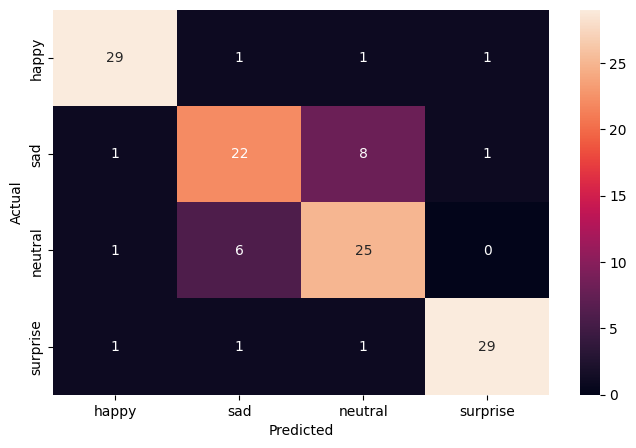

In [ ]:
# Get a clean grayscale test set for our best model (Model7) — no shuffle so labels stay aligned
_, _, test_m7 = make_data_loaders('grayscale', rescale=1./255)

# Get the model's predicted class for each test image
pred = model7.predict(test_m7)
pred = np.argmax(pred, axis=1)        # pick the emotion with the highest predicted probability
y_true = test_m7.classes              # the true labels (aligned because shuffle=False)

# Per-class precision, recall, and F1 — shows how well each emotion is detected
print(classification_report(y_true, pred,
                            target_names=['happy', 'sad', 'neutral', 'surprise']))

# Confusion matrix: diagonal = correct predictions, off-diagonal = mistakes between classes
cm = confusion_matrix(y_true, pred)
plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='.0f',
            xticklabels=['happy', 'sad', 'neutral', 'surprise'],
            yticklabels=['happy', 'sad', 'neutral', 'surprise'])
plt.ylabel('Actual')      # rows = true emotion
plt.xlabel('Predicted')   # columns = what the model guessed
plt.show()

**Observations and Insights:**

*   Overall test accuracy is 0.82 across the four emotions.
*   Happy (F1 0.91) and surprise (F1 0.92) are classified best — both have strong, distinct features (a smile; wide eyes and open mouth), so the model separates them easily.
*   Sad (F1 0.71) and neutral (F1 0.75) are the weakest and most confused with each other — sad recall is lowest at 0.69, with several sad faces predicted as neutral. This matches expectation, since a mild sad face looks very close to a neutral one.
*   The errors are concentrated almost entirely in the sad-neutral pair; the model rarely confuses the visually distinct classes (happy, surprise).

## **Conclusion:**

*   This project built and compared seven models to classify facial expressions into four emotions (happy, sad, neutral, surprise) on a dataset of 48x48 grayscale images.
*   We tested three from-scratch CNNs, three pre-trained transfer-learning models (VGG16, ResNet101V2, EfficientNetV2B2), and one tuned complex CNN.
*   The tuned Model 7 was the clear winner at 0.82 test accuracy.
*   Notably, the simple from-scratch CNNs outperformed all three large pre-trained transfer models — the opposite of what we'd normally expect.
*   The reason is resolution: the pre-trained models were designed for 224x224 color images, and at 48x48 their repeated downsampling discards almost all spatial detail before the classifier ever sees it.
*   A lightweight, purpose-built CNN matched to the small grayscale input proved the better fit.

### **Insights**

### **Refined insights**:
####What are the most meaningful insights from the data relevant to the problem?

*   The dataset is near-balanced across classes (~3,170-3,980 images each), so class imbalance was not a significant problem.
*   All images are 48x48 single-channel grayscale. Using RGB color mode gave no advantage — it only copies the same gray values across three channels, adding computation but no information.
*   Emotion labels carry natural overlap: sad and neutral are visually similar, which the confusion matrix confirmed as the model's main source of error (sad recall 0.69, mostly confused with neutral). Happy and surprise, with their distinct features, were classified most reliably (F1 ~0.91-0.92).

### **Comparison of various techniques and their relative performance**:
####How do different techniques perform? Which one is performing relatively better? Is there scope to improve the performance further?

*   From-scratch CNNs: Model 7 tuned (0.82), Model 3 RGB (0.73), Model 1 grayscale (0.65).
*   Model 2 failed to train (0.26) due to an unstable architecture.
Transfer learning: VGG16 (0.66), EfficientNet (0.59), ResNet (0.54) — all below the scratch CNNs.
*   The single biggest gain came from tuning Model 7: replacing Flatten with GlobalAveragePooling2D, simplifying the classifier head, adding label smoothing (0.1), and raising early-stopping patience lifted it from 0.70 to 0.82.


### **Proposal for the final solution design**:
####What model do you propose to be adopted? Why is this the best solution to adopt?

*   I propose Model 7 (the tuned complex grayscale CNN) as the final model.
*   It achieved the highest test accuracy (0.82), clearly ahead of every other model including all three large pre-trained networks.
*   It is lightweight and efficient: it uses single-channel grayscale input (no wasted color channels) and far fewer resources than the transfer models, making it faster to train and run.
*   It generalizes well — the confusion matrix shows strong, balanced performance across all four emotions, with errors limited mainly to the naturally similar sad/neutral pair.
*   It proves the key lesson of this project: for small 48x48 grayscale images, a purpose-built simple CNN beats large pre-trained models designed for big color images. Model 7 is both the most accurate and the most practical choice.

###**Executive summary**
#### What are the most important findings from the analysis done in Milestone
*    **Data quality** directly determines model performance. The dataset was near-balanced across the four emotion classes (~3,170 - 3,980 images each), which supported fair training without bias toward any one emotion. A well-distributed, clean dataset is the foundation — a model can only learn reliably when the training data represents all classes consistently.
*    **The right technique must match the data.** Models built from scratch significantly outperformed all three pre-trained transfer learning models (VGG16, ResNet101V2, EfficientNetV2B2). Transfer learning models are pre-trained on large, high-resolution color (RGB) images, but our dataset consists of small 48x48 grayscale faces. At this resolution, repeated downsampling inside the transfer models collapses the image to almost no detail before the classifier sees it — so the pre-trained features add little value. A purpose-built lightweight CNN matched to the actual data characteristics was the better choice.
*    **Visual distinction between classes directly affects prediction accuracy.** Emotions with strong, clear visual cues — happy (smile, raised cheeks) and surprise (wide eyes, open mouth) — were classified most reliably (F1 ~0.91 - 0.92). Emotions with overlapping features — sad and neutral — were the most confused pair. This confirms that the harder the emotion is for a human to distinguish visually, the harder it is for a model too.

#### Provide the final proposed model specifications
*    Model Architecture - A Convolutional Neural Network (CNN) was chosen because it preserves spatial relationships in images — the position of eyes relative to the nose and mouth carries meaning that a flat fully-connected (ANN) network would lose. Model 7 uses five convolutional blocks, each with Conv2D → BatchNormalization → LeakyReLU → MaxPooling2D, which progressively extract features from simple edges to complex facial patterns. During tuning, Flatten was replaced with GlobalAveragePooling2D, which reduced overfitting and improved generalization by summarizing each feature map into a single value.
*    Input Dimensions - All images in the dataset are 48x48 pixels single-channel grayscale. This was confirmed during EDA and used consistently across all model configurations: input_shape=(48, 48, 1).
*    Loss Function - CategoricalCrossentropy with label_smoothing=0.1 added during tuning because emotion labels carry natural ambiguity (a mild sad face resembles neutral). Smoothing prevents the model from becoming overconfident on uncertain labels, which improved generalization.
*    Optimizer - Adam optimizer with an initial learning rate of 0.001. ReduceLROnPlateau (factor=0.2, patience=3) automatically reduced the learning rate when validation accuracy stopped improving, allowing the model to fine-tune in smaller steps rather than overshooting.
5. Epochs and Batch Size - Maximum epochs were set to 30 with EarlyStopping (patience=10) monitoring validation accuracy and restoring the best weights automatically. Model 7 trained to epoch 22 before early stopping kicked in, preventing overfitting as training accuracy diverged from validation. Batch size was set to 32 — small enough to generalize well without exhausting GPU memory.
6. Evaluation Metrics - Model performance was measured using test accuracy, loss, and a full classification report (precision, recall, F1-score per class) alongside a confusion matrix.

###**Problem and solution summary**

#### Summary of the problem
*    The goal is to build a deep learning model that can look at a picture of someone's face and correctly identify their emotion — happy, sad, surprise, or neutral.
*    Teaching machines to read facial expressions is a key part of emotional AI, and it has real uses: making human-computer interaction feel more natural, helping us understand human behavior, and supporting mental health assessments.

#### Explain the reason for the proposed solution design
  *   Several reasons led to the proposed design:
      * Nature of the data: Because the data is images, we can use a powerful CNN model, which is able to analyze thousands of data points to train on — and in return gives us a trained model with a high prediction rate.
      * Automation and scalability: A deep learning facial emotion model can predict human emotions at a near human-like level, and it keeps improving as more data is added. These models can be fine-tuned to closely mimic how humans interpret facial expressions, improving interaction between people and machines.
#### How it would affect the problem/business?

*   A deep learning model that predicts human emotions could be impactful across many business scenarios:
    *   Health monitoring: Facial emotion predictions could help understand a patient's or customer's psychological state.
    *   Safety and security: Emotion prediction could flag anything unusual or needing attention, helping prevent potential incidents before they escalate.
    *   Customer service: Businesses could analyze user behavior in real time and respond based on it — for example, detecting frustration and adjusting the interaction accordingly.


### **Recommendations for implementation**

#### What are some key recommendations to implement the solutions?
* Here are some key recommendations to implement the facial emotion recognition solution effectively:
  *   Input data quality and enhancement: As mentioned throughout, good predictions can only come from good input data. Data quality helps models learn the clear differences between emotions. These models could be further improved by enhancing the input images — adding more varied facial expressions, and potentially expanding beyond the 4 basic classes we used.
  *   Model selection and tuning: As we saw, building models with different convolutional blocks and more layers can produce very different, more powerful results. Tuning the model further (as we did with Model 7) can make it even more effective.
  *   Transfer learning: Although transfer learning did not work well in our scenario due to the nature of the input data (small, grayscale images), pre-trained models can be a valuable addition in other cases — for example, with larger, higher-resolution color images.
  *   Testing and validation: Splitting the input data into three separate sets — training, validation, and test — is essential. It lets us evaluate a model on unseen data and fairly compare models against each other to understand each one's true prediction power.
  *   Ethical considerations and privacy: This is one of the most important and most overlooked areas in modern technology. Clear user consent is essential so people know their facial data is being used, and keeping that data secure is critical — arguably one of the hardest challenges in the field.
  *   Industry-specific customization: As mentioned, facial emotion models can be applied across many business areas. Customizing the model for each specific industry would make it even more powerful and impactful.

#### What are the key actionables for stakeholders? What is the expected benefit and/or costs?
*   To effectively implement the facial emotion recognition models, stakeholders should focus on the following:
  *   Data strategy: Build a reliable process for collecting, cleaning, and storing a large, diverse set of quality images for training. This has the biggest impact on how well the model performs, but it also carries real costs — both in gathering the data and in the storage infrastructure needed to hold it.
  *   Technical infrastructure: Set up scalable, secure infrastructure to support model training, deployment, and day-to-day operation. Using cloud infrastructure or on-premise services with built-in scalability can save significant cost, and applying cost-optimization methods can reduce spending further.
  *   Compliance and regulatory: Put policies in place to comply with data privacy laws and ethical guidelines. In the USA, failing to meet requirements from regulatory bodies (such as the CFPB) can expose companies to large fines — so compliance is not optional.
  *   Performance monitoring: Set up real-time monitoring to track how the model performs once deployed. As a certified AWS cloud professional, I can say cloud platforms offer many monitoring tools that provide 24/7 oversight and save businesses considerable money by catching issues early.

*   Expected benefits: These actions give businesses a robust, profitable setup with stronger, data-driven decision-making. They can lead to improved customer engagement, and add value in areas like customer service and marketing through greater efficiency and productivity.
*   Costs: There will be both upfront costs (data collection) and ongoing operational costs. However, the enhanced insights the emotion recognition model provides can generate significant value — driving increased revenue and stronger customer loyalty that outweigh the initial investment.


#### What are the key risks and challenges?
*   Implementing a facial emotion recognition solution carries several important risks that need to be addressed:
  * Data privacy and ethical concerns: Collecting and processing facial images raises privacy issues around consent and potential misuse of personal data. To mitigate this, comply with data protection laws (e.g. GDPR), get clear consent from users, anonymize stored data, and only keep images as long as they are actually needed.
  * Bias in data and model: The model can inherit bias from its training data and perform worse for some demographic groups than others. To mitigate this, train on a diverse dataset representing different ages, ethnicities, and genders, and test accuracy separately for each group — a good overall average can hide poor performance on a minority group.
  * Accuracy and reliability: The model may struggle with different lighting, camera angles, or faces unlike those it trained on. Our own results already show accuracy is limited by low-resolution grayscale images and naturally similar emotions (sad vs neutral). To mitigate this, use data augmentation, train on higher-resolution images where possible, test in real-world conditions before deployment, and retrain periodically as new data arrives.
  * Interpretation and misuse of predictions: Stakeholders may over-trust the model's output and act on it directly — a serious problem in sensitive areas like mental health or security, where a wrong prediction has real consequences. To mitigate this, treat predictions as a signal rather than a verdict, show confidence scores alongside results, keep a human in the loop for important decisions, and train staff on how to read the output.


#### What further analysis needs to be done or what other associated problems need to be solved?

*   Several areas would benefit from additional work before this solution is production-ready:
  * Higher-resolution image testing: Our biggest limitation was the 48×48 grayscale input, which capped how well any model could perform and directly explains why the large pre-trained models underperformed. Training and evaluating on higher-resolution color images would show how much accuracy is being lost to resolution alone, and would likely allow transfer learning to work as intended.
  * Fine-tuning the transfer learning models: We froze the pre-trained layers entirely. Unfreezing the top blocks and training them at a low learning rate would let those ImageNet features adapt to facial expressions, and would tell us whether transfer learning genuinely fails at this task or simply needs adjustment.
  * Improving the sad/neutral distinction: The confusion matrix shows nearly all errors are concentrated in this one pair. Further analysis could explore targeted approaches — collecting more clearly-labeled examples of each, adding a confidence threshold, or treating ambiguous cases as a separate category rather than forcing a choice.
  * Expanding the emotion classes: We used four emotions, but real-world applications need a broader range (anger, fear, disgust). Adding classes would test whether the model's performance holds as the problem becomes harder and the classes become more visually similar.
  * Testing for demographic bias: Our evaluation measured overall accuracy only. A proper analysis would break down performance by age, ethnicity, and gender to confirm the model works fairly across groups — a necessary step before any real deployment.
  * Real-world validation: All results come from a clean, curated dataset. The model needs testing on live images with varied lighting, camera angles, and partial occlusion (glasses, hands, hair) to confirm it holds up outside controlled conditions.

In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/Reference_Notebook_Facial_Emotion_Detection_Full_Code_Final.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Reference_Notebook_Facial_Emotion_Detection_Full_Code_Final.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 1868964 bytes to /content/drive/MyDrive/Colab Notebooks/Reference_Notebook_Facial_Emotion_Detection_Full_Code_Final.html
